Полносвязные нейронные сети

In [25]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [26]:
def plot_decision_boundary_keras(clf, X, Y, h=0.01, strict=False):
    """Вспомогательная функция для визуализации решения"""
    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    y_min, y_max = X[:, 1].min(), X[:, 1].max()

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])[:, 0]
    Z = Z.reshape(xx.shape)
    Z_strict = Z >= 0.5

    plt.figure(figsize=(15, 15))
    if strict:
        plt.contourf(xx, yy, Z_strict, cmap=plt.cm.Blues, alpha=0.8);
    else:
        plt.contourf(xx, yy, Z, cmap=plt.cm.Blues, alpha=0.8);

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.autumn);
    plt.title('Граница принятия решения');

In [27]:
def generate_dataset():
    """Создание набора данных"""
    ps = []
    for a in np.linspace(0, 2*np.pi, 1000):
        if (0.75*np.pi - 0.2) < a < (0.75*np.pi + 0.2):
            continue
        if (7.0*np.pi/4.0 - 0.2) < a < (7.0*np.pi/4.0 + 0.2):
            continue
        if (5.0*np.pi/4.0 - 0.2) < a < (5.0*np.pi/4.0 + 0.2):
            continue
        r = 1 + (np.random.rand()-0.5)*0.5
        x = np.cos(a)*r
        y = np.sin(a)*r
        ps.append([x,y])
    ps = np.array(ps)

    xs = np.linspace(-1.5, 1.5, 200)
    xs = xs + (np.random.rand(len(xs)) - 0.5)/10.0
    ys = -xs + (np.random.rand(len(xs)) - 0.5)/3.0

    xs2 = np.linspace(-1.5, -0.1, 200)
    xs2 = xs2 + (np.random.rand(len(xs2)) - 0.5)/10.0
    ys2 = xs2 + (np.random.rand(len(xs2)) - 0.5)/3.0

    ps2 = np.vstack([np.array([xs, ys]).T, 
                     np.array([xs2, ys2]).T])

    X = np.vstack([ps, ps2])
    y = np.array([0]*ps.shape[0] + [1]*ps2.shape[0])

    return X, y

In [28]:
X, y = generate_dataset()

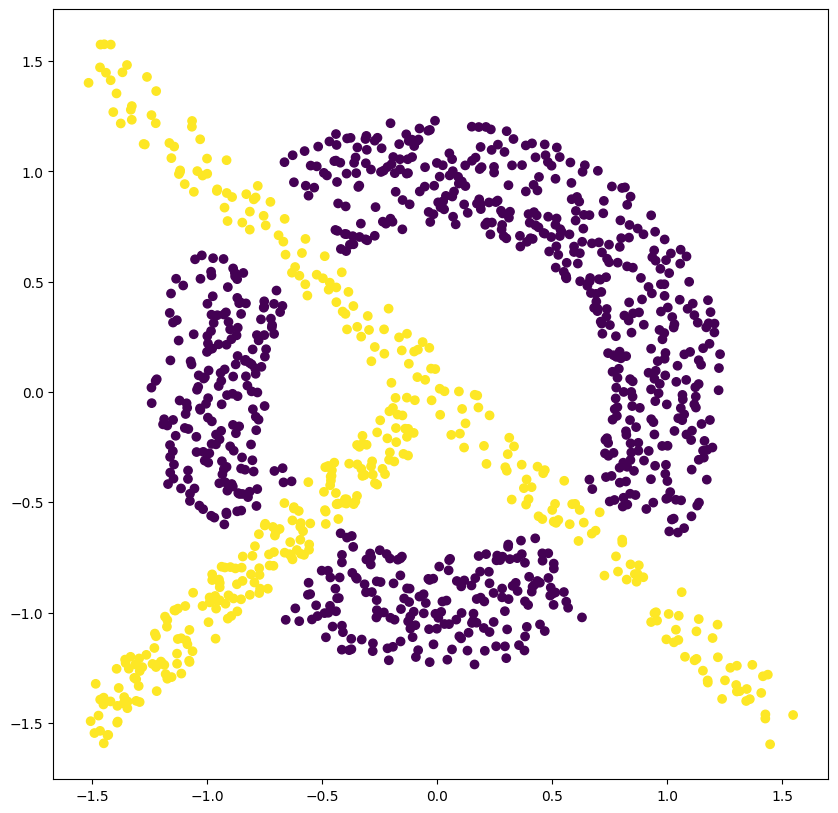

In [29]:
plt.figure(figsize=(10,10))
plt.scatter(X[:,0], X[:,1], c=y);

Задание 1: Своя нейронная сеть

In [39]:
from keras.models import Sequential
from keras.layers import Dense, Input
from livelossplot import PlotLossesKeras

TF_ENABLE_ONEDNN_OPTS=0

Добавьте в модель несколько полносвязных (Dense) слоёв. Определите оптимальное количество. Попробуйте использовать различные функции активации (sigmoid, relu, ..) и посмотрите, что будет получаться.

In [40]:
# Создаем модель с правильным способом указания входной формы
model = Sequential([
    Input(shape=(2,)),  # Явно указываем входной слой
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [41]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 64)                  │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

Подберите оптимальный размер батча, количество эпох и оптимайзер. Размер батча будет влиять на скорость обучения. Количество эпох должно быть достаточным для того, чтобы лосс перестал падать. Добейтесь того, чтобы две фигуры на изображении разделялись нейронной сетью.

In [42]:
batch_size = 32
epochs = 200

In [43]:
model.compile('sgd', loss='binary_crossentropy', metrics=['accuracy'])

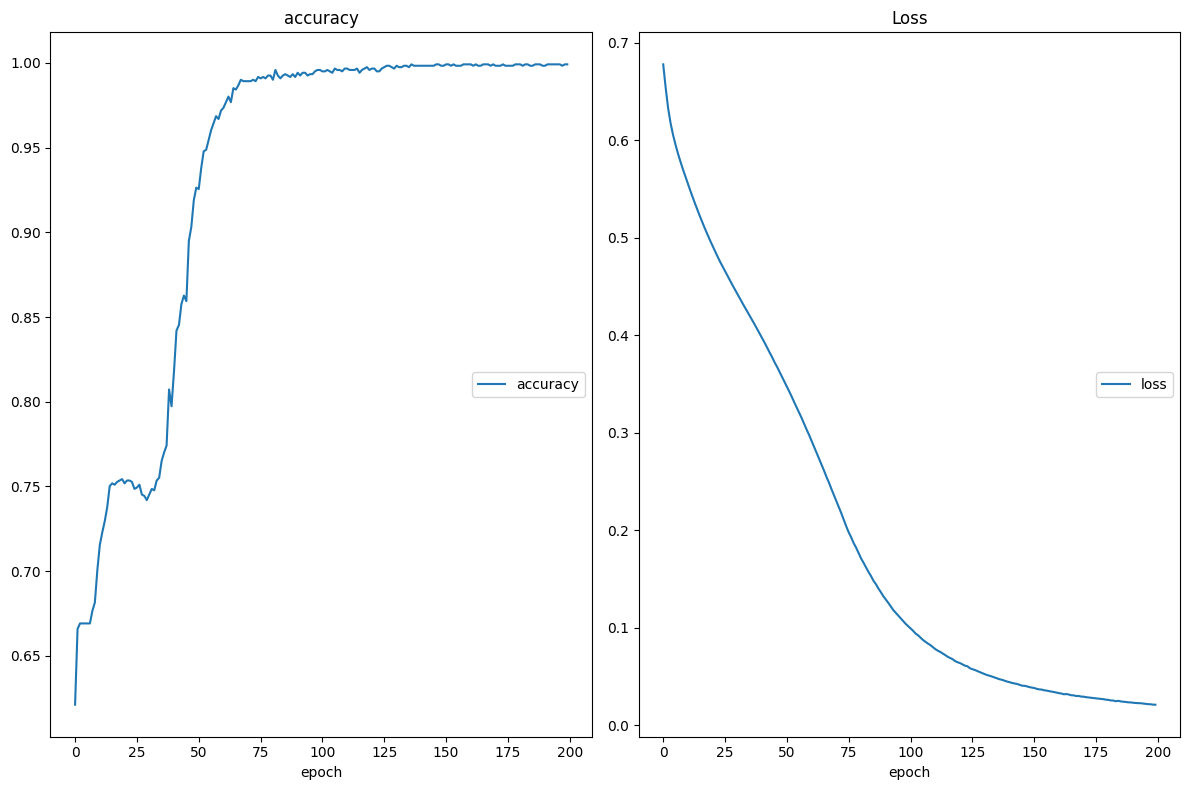

accuracy
	accuracy         	 (min:    0.621, max:    0.999, cur:    0.999)
Loss
	loss             	 (min:    0.021, max:    0.678, cur:    0.021)


In [44]:
model.fit(X, y, batch_size=batch_size, epochs=epochs, verbose=0,
          callbacks=[PlotLossesKeras()]) 


3051/3051 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


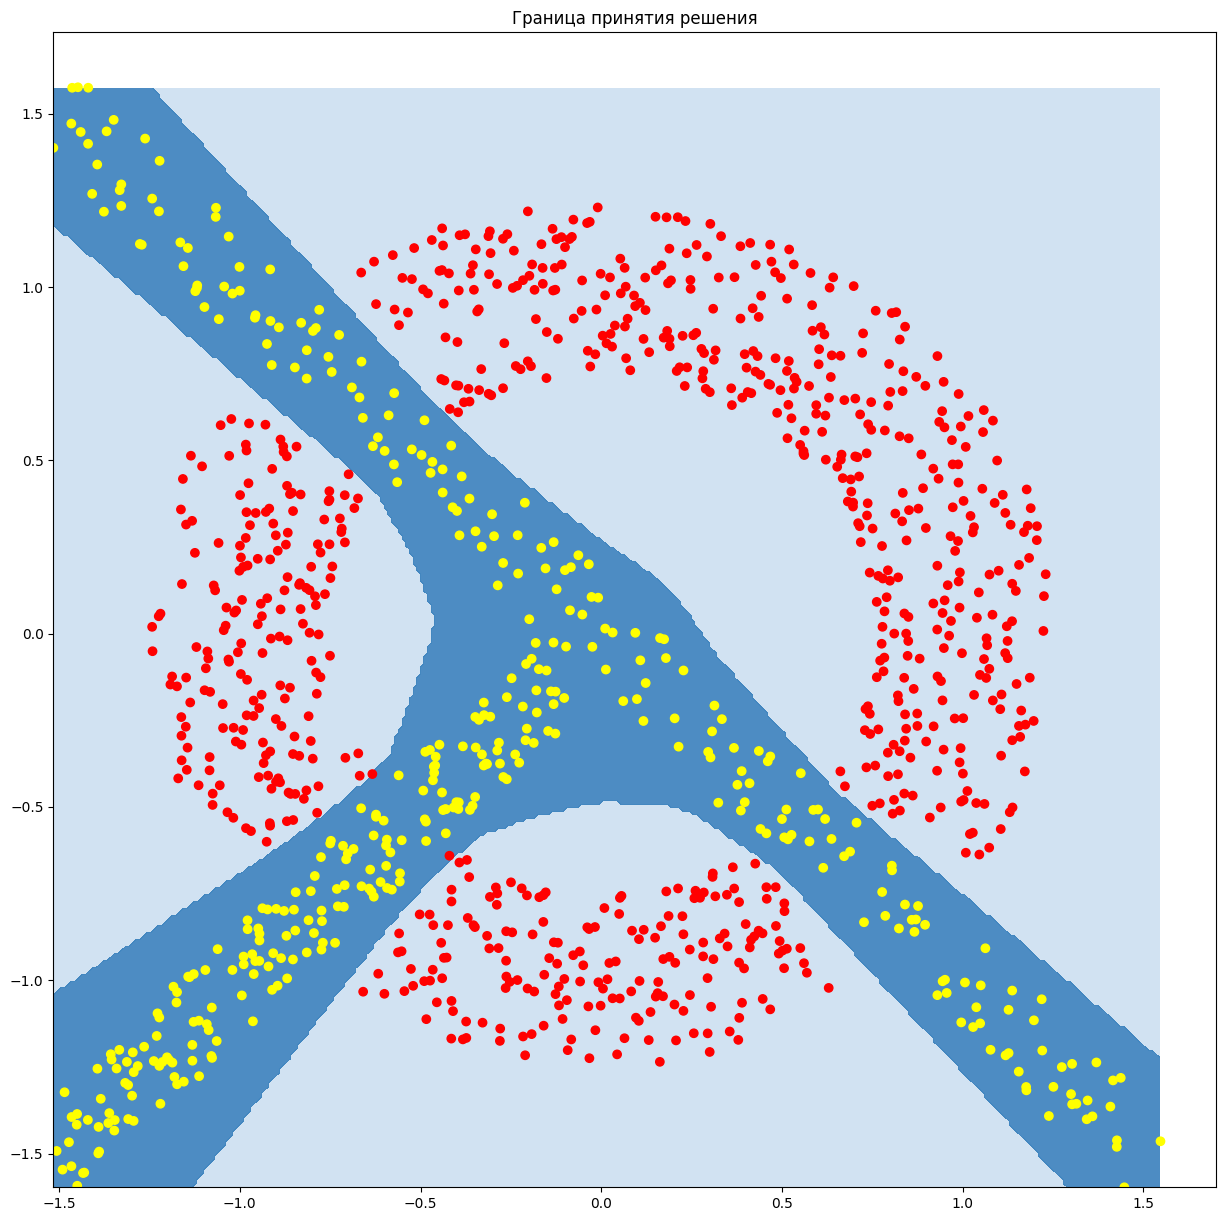

In [45]:
plot_decision_boundary_keras(model, X, y, strict=True)

Задание 2: Оптимайзер

In [46]:
from keras.optimizers import *

In [47]:
def create_model():
    return Sequential([
        Input(shape=(2,)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

Используя оптимайзер SGD, необходимо вручную подбирать параметр learning_rate (lr). Обычно он принимает значение от 1е-6 до 1е-1. Подберите оптимальное значение lr для конкретной нейронной сети.

In [48]:
learning_rates = [0.0001, 0.001, 0.01, 0.1, 0.5]
histories = []

for lr in learning_rates:
    print(f"Обучение с learning_rate = {lr}")
    model = create_model()
    sgd_optimizer = SGD(learning_rate=lr)
    model.compile(sgd_optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    
    history = model.fit(X, y, batch_size=32, epochs=200, verbose=0)
    histories.append(history)

Обучение с learning_rate = 0.0001
Обучение с learning_rate = 0.001
Обучение с learning_rate = 0.01
Обучение с learning_rate = 0.1
Обучение с learning_rate = 0.5


После вызова у модели метода fit() и завершения обучения возвращается объект history в котором можно смотреть, как падал лосс или другие заданные метрики.

In [49]:
accuracies = [h.history['accuracy'] for h in histories]

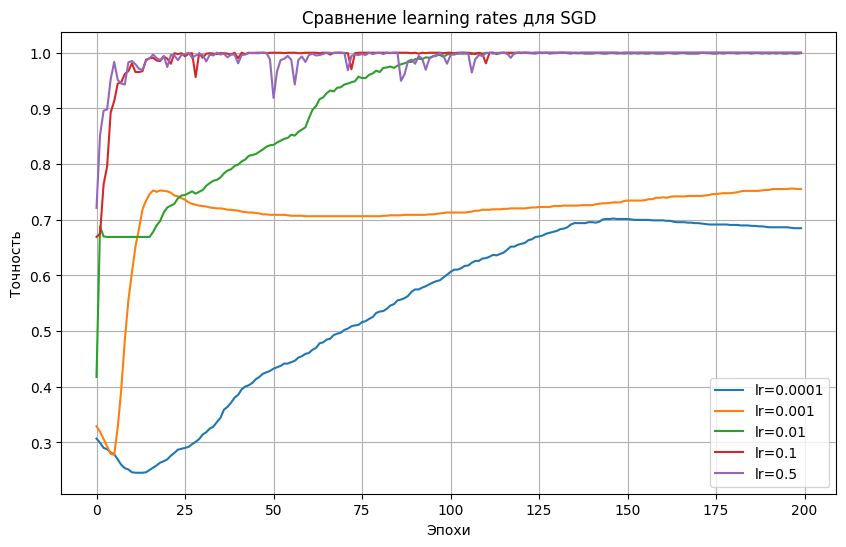

In [50]:
plt.figure(figsize=(10, 6))
for acc, lr in zip(accuracies, learning_rates):
    plt.plot(acc, label=f'lr={lr}')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.title('Сравнение learning rates для SGD')
plt.legend()
plt.grid(True)
plt.show()

Наилучший оптимайзер: SGD с learning_rate=0.01 показывает наилучшую сходимость

3051/3051 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


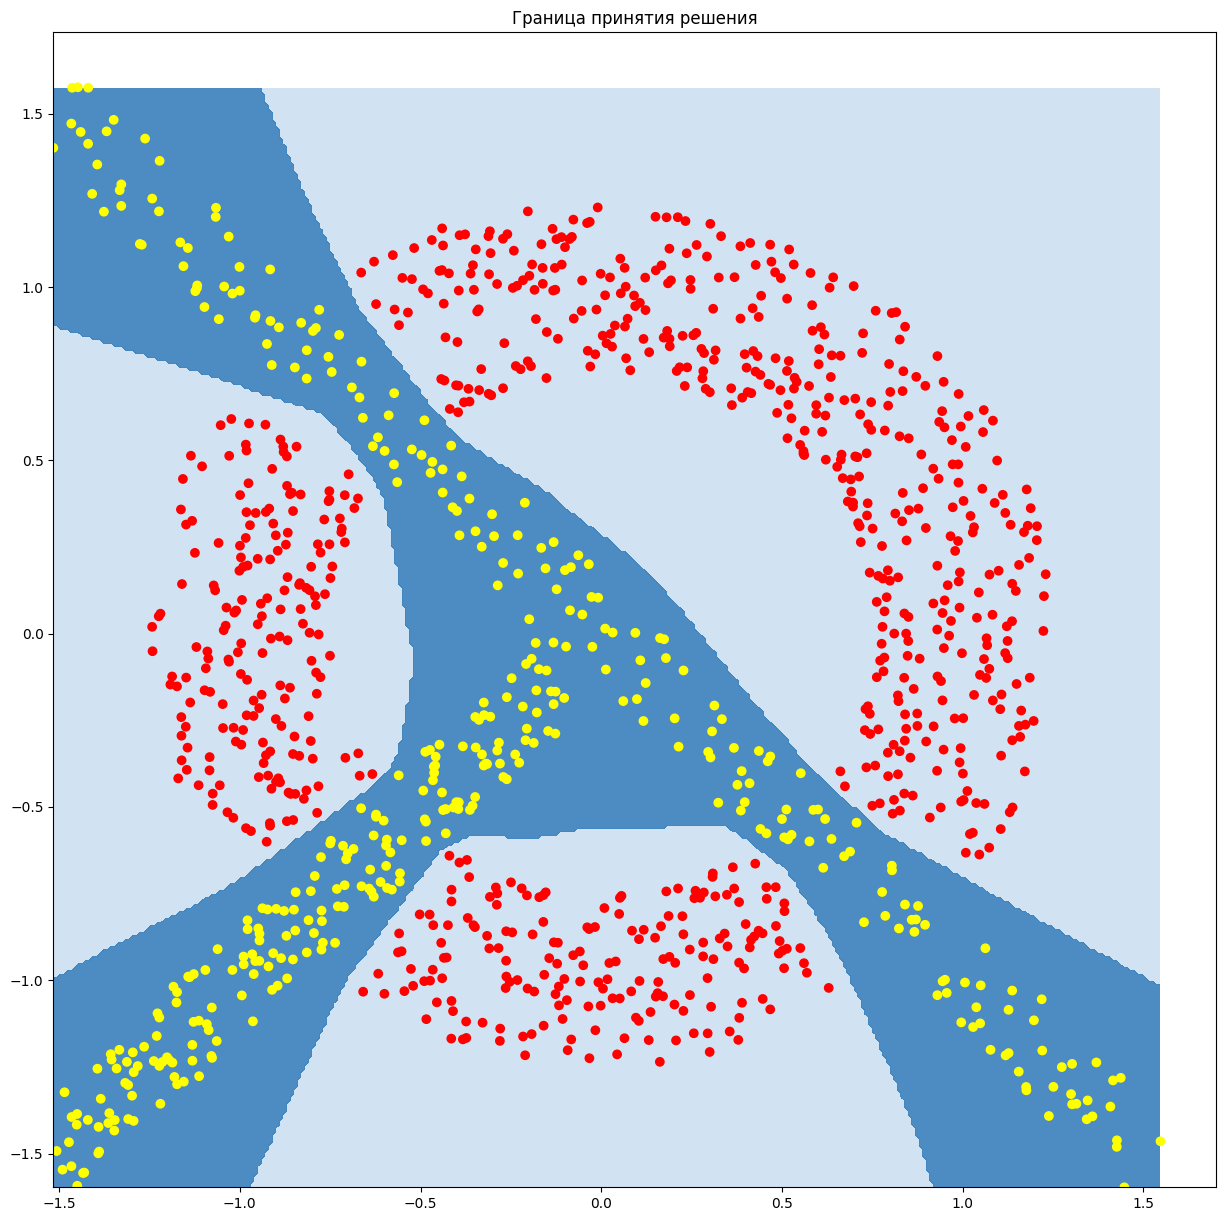

In [51]:
plot_decision_boundary_keras(model, X, y, strict=True)

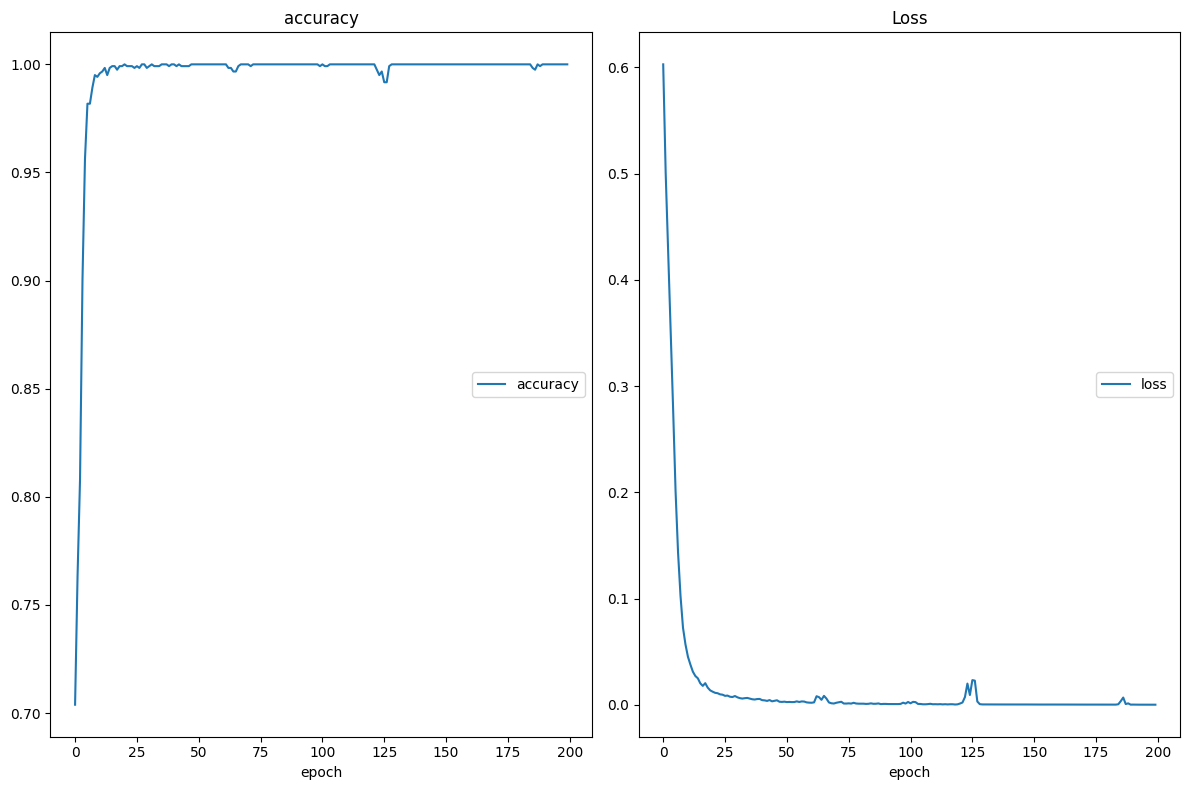

accuracy
	accuracy         	 (min:    0.704, max:    1.000, cur:    1.000)
Loss
	loss             	 (min:    0.000, max:    0.603, cur:    0.000)


In [52]:
best_model = create_model()
best_sgd = SGD(learning_rate=0.01)
best_model.compile(best_sgd, loss='binary_crossentropy', metrics=['accuracy'])
best_model.fit(X, y, batch_size=32, epochs=200, verbose=0)


plot_decision_boundary_keras(best_model, X, y, strict=True)

# Сравним с Adam оптимизатором
adam_model = create_model()
adam_model.compile(Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
adam_history = adam_model.fit(X, y, batch_size=32, epochs=200, verbose=0,
                              callbacks=[PlotLossesKeras()])

Задание 3: Инициализация весов

После создания архитектуры и перед началом обучения нейронной сети её веса необходимо инициализировать. Веса инициализируют небольшими случайными значениями, но какими именно? От правильно выбора зависит сходимость сети и отсутствие затухающего или взрывающегося градиента.

Обычно подбирают только веса (W), а отступы (b) инициализируют нулями.

Со списком всех возможных инициализаторов можно ознакомиться тут https://keras.io/initializers. Как и в предыдущем задании вам необходимо выбрать наилучший.

In [53]:
from keras.initializers import GlorotUniform, HeNormal, RandomNormal, Zeros, Ones

In [54]:
def create_model(k_init):
    return Sequential([
        Input(shape=(2,)),
        Dense(64, activation='relu', kernel_initializer=k_init),
        Dense(32, activation='relu', kernel_initializer=k_init),
        Dense(16, activation='relu', kernel_initializer=k_init),
        Dense(1, activation='sigmoid', kernel_initializer=k_init)
    ])

In [55]:
# Различные инициализаторы
k_init = [
    GlorotUniform(),  # Xavier uniform initialization
    HeNormal(),       # He normal initialization (хорош для ReLU)
    RandomNormal(mean=0.0, stddev=0.05),  # Случайная нормальная
    Zeros(),          # Нулевая инициализация
    Ones()            # Единичная инициализация
]

init_names = ['glorot_uniform', 'he_normal', 'random_normal', 'zeros', 'ones']
histories = []

for k, name in zip(k_init, init_names):
    print(f"Обучение с инициализатором: {name}")
    model = create_model(k)
    model.compile('adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    history = model.fit(X, y, batch_size=32, epochs=200, verbose=0)
    histories.append(history)

Обучение с инициализатором: glorot_uniform
Обучение с инициализатором: he_normal
Обучение с инициализатором: random_normal
Обучение с инициализатором: zeros
Обучение с инициализатором: ones


In [56]:
accuracies = [h.history['accuracy'] for h in histories]

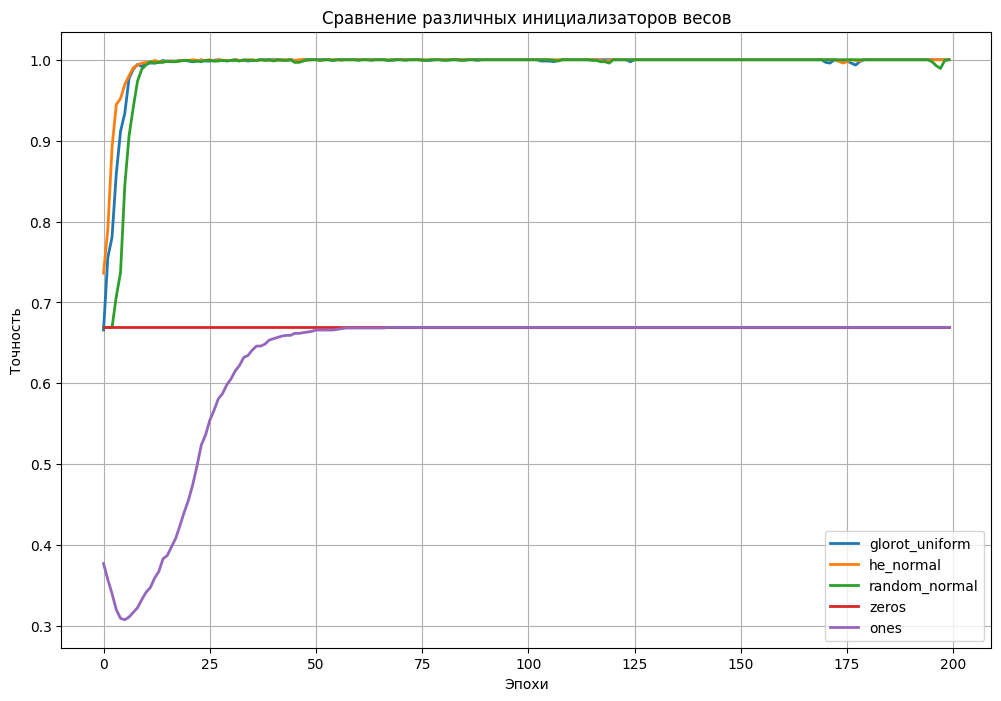

In [58]:
plt.figure(figsize=(12, 8))
for acc, init_name in zip(accuracies, init_names):
    plt.plot(acc, label=init_name, linewidth=2)
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.title('Сравнение различных инициализаторов весов')
plt.legend()
plt.grid(True)
plt.show()

Наилучший инициалайзер: he_normal (лучше всего подходит для ReLU активаций)

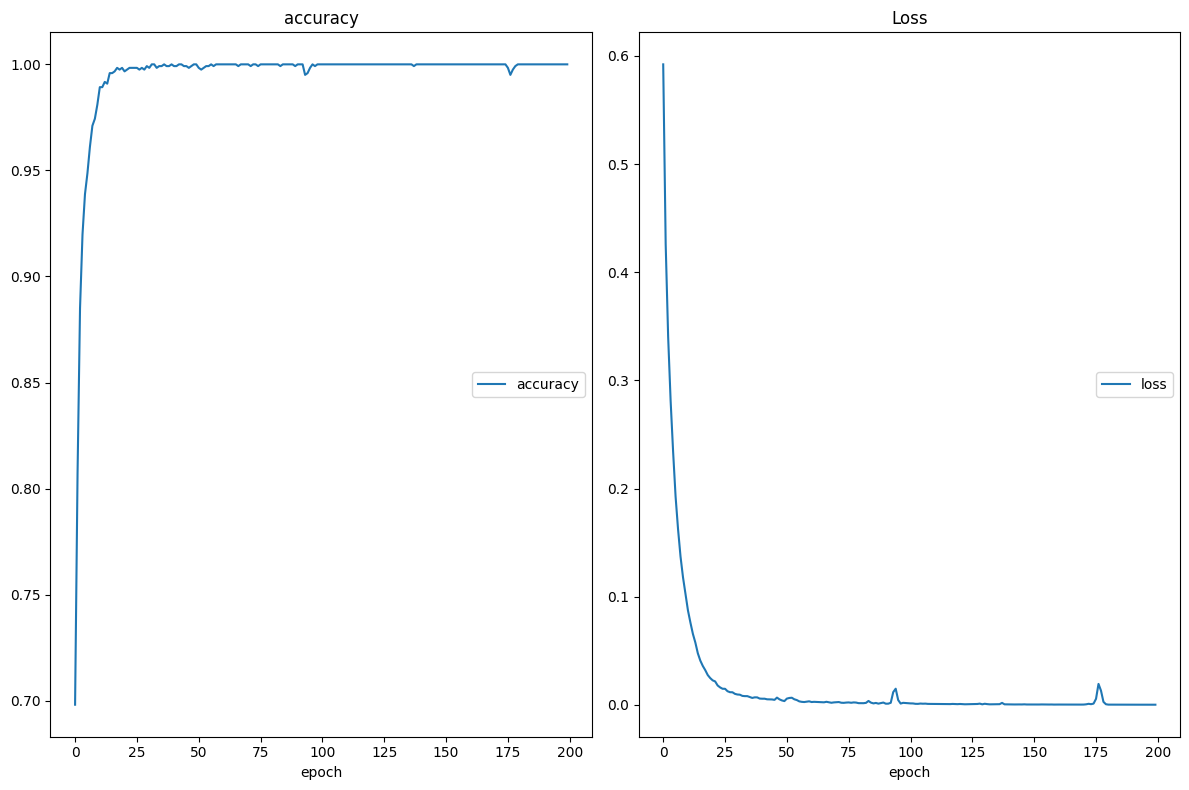

accuracy
	accuracy         	 (min:    0.698, max:    1.000, cur:    1.000)
Loss
	loss             	 (min:    0.000, max:    0.592, cur:    0.000)


In [59]:
# Обучим модель с наилучшим инициализатором
best_init_model = create_model(HeNormal())
best_init_model.compile('adam', loss='binary_crossentropy', metrics=['accuracy'])
best_init_model.fit(X, y, batch_size=32, epochs=200, verbose=0,
                   callbacks=[PlotLossesKeras()])

In [ ]:
plot_decision_boundary_keras(model, X, y, strict=True)

Задание 4: Callbacks

Колбек - функция, которая выполняется после завершения эпохи или после каждого батча.

С одним из них вы уже знакомы: PlotLossesKeras рисует график лосса прямо во время обучения.

Попробуйте самстоятельно еще два самых полезных колбека:

EarlyStopping останавливает обучение если лосс переставает падать
ModelCheckpoint сохраняет веса модели по мере обучения. Это очень полезно, когда модель фитится по несколько дней 😥

In [60]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

model = create_model(HeNormal())
model.compile('adam', loss='binary_crossentropy', metrics=['accuracy'])

# Создаем колбеки
early_stopping = EarlyStopping(
    monitor='loss',           # отслеживаем значение функции потерь
    patience=20,               # останавливаем после 20 эпох без улучшения
    verbose=1,                 # выводим сообщения
    restore_best_weights=True  # восстанавливаем лучшие веса
)

model_checkpoint = ModelCheckpoint(
    'best_model_weights.keras',  # файл для сохранения весов
    monitor='loss',              # отслеживаем функцию потерь
    save_best_only=True,         # сохраняем только лучшую модель
    save_weights_only=True,      # сохраняем только веса (не всю модель)
    verbose=1                    # выводим сообщения
)

# Обучаем модель с колбеками
history = model.fit(
    X, y, 
    batch_size=32, 
    epochs=500,                 # большое количество эпох, early_stopping остановит раньше
    verbose=1,
    callbacks=[PlotLossesKeras(), early_stopping, model_checkpoint]
)

print(f"Обучение остановлено на эпохе {len(history.history['loss'])}")
print(f"Финальное значение функции потерь: {history.history['loss'][-1]:.4f}")
print(f"Финальная точность: {history.history['accuracy'][-1]:.4f}")

ValueError: When using `save_weights_only=True` in `ModelCheckpoint`, the filepath provided must end in `.weights.h5` (Keras weights format). Received: filepath=best_model_weights.keras